Calculating Ra for a range of permabilities and sediment thicknesses

/var/folders/7g/dgg32wkn3yq399tbv2t26xn40000gn/T/ipykernel_51607/2942586539.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)


s = 0 m
L = 500 m
P_top = 135.20 MPa
P_bot = 135.20 MPa
P_mid = 135.20 MPa
λ_bulk = 2.1675 W/m·K
T_top = 2.00 °C
T_bot = 4.31 °C
T_mid = 3.15 °C
ΔT = 2.31 °C
μ = 1.5594e-03 Pa·s
α = 2.0000e-04 1/K
s = 200 m
L = 500 m
P_top = 135.47 MPa
P_bot = 135.74 MPa
P_mid = 135.61 MPa
λ_bulk = 2.1675 W/m·K
T_top = 2.92 °C
T_bot = 6.15 °C
T_mid = 4.54 °C
ΔT = 3.23 °C
μ = 1.4970e-03 Pa·s
α = 2.0000e-04 1/K
s = 1000 m
L = 500 m
P_top = 136.55 MPa
P_bot = 137.91 MPa
P_mid = 137.23 MPa
λ_bulk = 2.1675 W/m·K
T_top = 6.61 °C
T_bot = 13.53 °C
T_mid = 10.07 °C
ΔT = 6.92 °C
μ = 1.2808e-03 Pa·s
α = 2.0000e-04 1/K
s = 5000 m
L = 500 m
P_top = 141.97 MPa
P_bot = 148.75 MPa
P_mid = 145.36 MPa
λ_bulk = 2.1675 W/m·K
T_top = 25.07 °C
T_bot = 50.44 °C
T_mid = 37.76 °C
ΔT = 25.37 °C
μ = 6.7995e-04 Pa·s
α = 2.0000e-04 1/K
s = 0 m
L = 1000 m
P_top = 135.20 MPa
P_bot = 135.20 MPa
P_mid = 135.20 MPa
λ_bulk = 2.1675 W/m·K
T_top = 2.00 °C
T_bot = 6.61 °C
T_mid = 4.31 °C
ΔT = 4.61 °C
μ = 1.5071e-03 Pa·s
α = 2.0000e-04 1/K


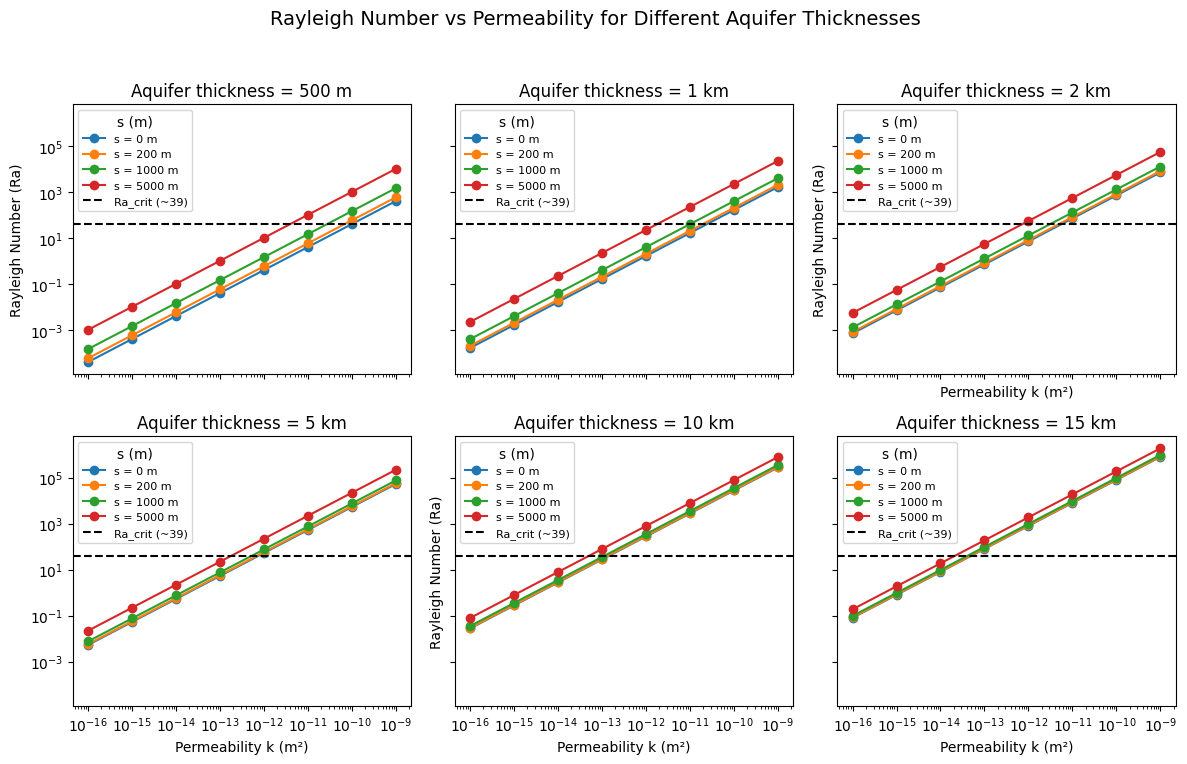

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the NIST data file
filename = "nist350-600.out"
# Read the file
# Assuming fixed-width formatting with whitespace separator
df = pd.read_csv(filename, delim_whitespace=True, header=None)
# Assign meaningful column names (adjust these if needed based on the file structure)
df.columns = [
    "Pressure_MPa","Temp_C", "Col3", "Col4", "Thermal_Expansivity", "Col6",
    "Col7", "Col8", "Col9", "Col10", "Col11"
]

# --- Fixed parameters ---
T_seafloor = 2                      # °C
P_seafloor = 135200000                  # Pa (135.2 MPa)
L = 10000                           # m (thickness of aquifer)
q = 0.01                            # W/m² at base
porosity_rock = 0.1                 # porosity of serpentinite
lam_rock = 2.5                      # W/m·K thermal conductivity of serpentinite
lam_sw = 0.6                        # W/m·K thermal conductivity of water
rho_sw = 1042                       # kg/m³ density of saewater
c_sw = 4100                         # J/kg·K heat capacity of seawater
g_eu = 1.3                          # m/s² gravity of Europa

# --- Functions ---
def compute_P_top(P_seafloor, s, rho_sw, g_eu):
    return (P_seafloor + (s * rho_sw * g_eu)) 

def compute_P_bot(P_top, s, L, rho_sw, g_eu):
    return (P_top + s * rho_sw * g_eu) 

def compute_P_mid(P_top, P_bot):
    return (P_top + P_bot) / 2

def compute_lam_bulk(lam_rock, lam_sw, porosity_rock):
    return (lam_sw**porosity_rock) * (lam_rock**(1-porosity_rock))  # top is same as seafloor

def compute_T_top(T_seafloor, q, s, lam_bulk):
    return T_seafloor + (q/lam_bulk) * s  # top of aq

def compute_T_bot(T_top, q, s, L, lam_bulk):
    return T_top + (q/lam_bulk) * (s+L)  # bottom of aq

def compute_T_mid(T_top, T_bot): 
    return (T_top + T_bot)/2 # mid of aq
    
# Function to get the closest match for a given temperature and pressure
def lookup_alpha(temp_C, pressure_MPa):
    pressure_MPa = pressure_MPa / 1000000
    # Create a temporary series of differences (do NOT assign to the DataFrame)
    diffs = np.abs(df['Temp_C'] - temp_C) + np.abs(df['Pressure_MPa'] - pressure_MPa)
    
    # Get the index of the closest match
    idx = diffs.idxmin()
    
    # Return the thermal expansivity value from that row
    return df.loc[idx, 'Thermal_Expansivity']

def compute_mu(T):
    return np.exp(-10.7079 + 604.129 / (139.18 + T))

def compute_delta_T(T_top, T_bot):
    return T_bot - T_top

def compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk):
    return (alpha * rho_sw**2 * c_sw * k * L * g_eu * delta_T) / (mu * lam_bulk)

# --- Parameter ranges ---
k_values = np.logspace(-16, -9, num=8)
s_values = [0, 200, 1000, 5000] # sediment thickness in m
L_values = [500, 1000, 3000, 5000, 10000]  # aquifer thickness in m

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dummy NIST data setup (for demo purposes)
# Replace this with actual file reading and processing if available
# df = pd.read_csv("nist350-600.out", delim_whitespace=True, header=None)
# df.columns = ["Pressure_MPa", "Temp_C", "Col3", "Col4", "Thermal_Expansivity", "Col6",
#               "Col7", "Col8", "Col9", "Col10", "Col11"]

# Simulate lookup_alpha using a dummy function
def lookup_alpha(temp_C, pressure_Pa):
    return 2e-4  # Placeholder

# Fixed parameters
T_seafloor = 2  # °C
P_seafloor = 135200000  # Pa
q = 0.01  # W/m²
porosity_rock = 0.1
lam_rock = 2.5
lam_sw = 0.6
rho_sw = 1042
c_sw = 4100
g_eu = 1.3

# Functions
def compute_P_top(P_seafloor, s, rho_sw, g_eu):
    return P_seafloor + (s * rho_sw * g_eu)

def compute_P_bot(P_top, s, L, rho_sw, g_eu):
    return P_top + s * rho_sw * g_eu

def compute_P_mid(P_top, P_bot):
    return (P_top + P_bot) / 2

def compute_lam_bulk(lam_rock, lam_sw, porosity_rock):
    return (lam_sw**porosity_rock) * (lam_rock**(1-porosity_rock))

def compute_T_top(T_seafloor, q, s, lam_bulk):
    return T_seafloor + (q / lam_bulk) * s

def compute_T_bot(T_top, q, s, L, lam_bulk):
    return T_top + (q / lam_bulk) * (s + L)

def compute_T_mid(T_top, T_bot):
    return (T_top + T_bot) / 2

def compute_mu(T):
    return np.exp(-10.7079 + 604.129 / (139.18 + T))

def compute_delta_T(T_top, T_bot):
    return T_bot - T_top

def compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk):
    return (alpha * rho_sw**2 * c_sw * k * L * g_eu * delta_T) / (mu * lam_bulk)

# Parameter ranges
k_values = np.logspace(-16, -9, num=8)
s_values = [0, 200, 1000, 5000]
L_values = [500, 1000, 2000, 5000, 10000, 15000]  # Aquifer thickness

# Plot setup
fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axs = axs.flatten()

Ra_conservative = 39.5
Ra_liberal = 100

for idx, L in enumerate(L_values):
    ax = axs[idx]
    for s in s_values:
        Ra_list = []
        for k in k_values:
            P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
            P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
            P_mid = compute_P_mid(P_top, P_bot)
            lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
            T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
            T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
            T_mid = compute_T_mid(T_top, T_bot)
            delta_T = compute_delta_T(T_top, T_bot)
            mu = compute_mu(T_mid)
            alpha = -lookup_alpha(T_mid, P_mid)
            alpha = -alpha
            
            Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
            Ra_list.append(Ra)

        ax.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
        print(f"s = {s} m")
        print(f"L = {L} m")
        print(f"P_top = {P_top / 1e6:.2f} MPa")
        print(f"P_bot = {P_bot / 1e6:.2f} MPa")
        print(f"P_mid = {P_mid / 1e6:.2f} MPa")
        print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
        print(f"T_top = {T_top:.2f} °C")
        print(f"T_bot = {T_bot:.2f} °C")
        print(f"T_mid = {T_mid:.2f} °C")
        print(f"ΔT = {delta_T:.2f} °C")
        print(f"μ = {mu:.4e} Pa·s")
        print(f"α = {alpha:.4e} 1/K")

    #ax.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2)
    ax.axhline(Ra_conservative, color='black', linestyle ='--', label= 'Ra_crit (~39)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    if L < 1000:
        ax.set_title(f"Aquifer thickness = {L:.0f} m")
    else:
        ax.set_title(f"Aquifer thickness = {L/1000:.0f} km")
    ax.grid(False)
    if idx % 2 == 0:
        ax.set_ylabel("Rayleigh Number (Ra)")
    if idx >= 2:
        ax.set_xlabel("Permeability k (m²)")
    ax.legend(title="s (m)", fontsize=8)

plt.suptitle("Rayleigh Number vs Permeability for Different Aquifer Thicknesses", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:


# --- Rayleigh number calculation and plotting ---
plt.figure(figsize=(8, 6))

for s in s_values:
    Ra_list = []
    for k in k_values:
        L = 500
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Permeability k (m²)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Permeability for Varying Depth to Aquifer Top and Aquifer Thickness = 500 m")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for k in k_values:
        L = 1000 
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Permeability k (m²)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Permeability for Varying Depth to Aquifer Top and Aquifer Thickness = 1 km")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for k in k_values:
        L= 2000
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Permeability k (m²)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Permeability for Varying Depth to Aquifer Top and Aquifer Thickness = 2 km")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()


for s in s_values:
    Ra_list = []
    for k in k_values:
        L = 5000
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Permeability k (m²)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Permeability for Varying Depth to Aquifer Top and Aquifer Thickness = 5 km")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for k in k_values:
        L = 10000
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(k_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Permeability k (m²)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Permeability for Varying Depth to Aquifer Top and Aquifer Thickness = 10 km")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for L in L_values:
        k = 10e-16
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(L_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
#plt.xscale('log')
plt.yscale('log')
plt.xlabel("Aquifer thickness (m)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Aquifer thickness for Varying Depth Top of Aquifer with k=12e-16")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for L in L_values:
        k = 10e-12
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(L_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
#plt.xscale('log')
plt.yscale('log')
plt.xlabel("Aquifer thickness (m)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Aquifer thickness for Varying Depth Top of Aquifer with k=12e-12")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()

for s in s_values:
    Ra_list = []
    for L in L_values:
        k = 10e-9
        P_top = compute_P_top(P_seafloor, s, rho_sw, g_eu)
        P_bot = compute_P_bot(P_top, s, L, rho_sw, g_eu)
        P_mid = compute_P_mid(P_top, P_bot)
        lam_bulk = compute_lam_bulk(lam_rock, lam_sw, porosity_rock)
        T_top = compute_T_top(T_seafloor, q, s, lam_bulk)
        T_bot = compute_T_bot(T_top, q, s, L, lam_bulk)
        T_mid = compute_T_mid(T_top, T_bot)
        delta_T = compute_delta_T(T_top, T_bot)
        mu = compute_mu(T_mid)
        alpha = lookup_alpha(T_mid, P_mid)
        alpha = - alpha

        Ra = compute_rayleigh(alpha, rho_sw, c_sw, k, L, g_eu, delta_T, mu, lam_bulk)
        Ra_list.append(Ra)
    plt.plot(L_values, Ra_list, marker='o', label=f's = {s} m')
# --- Plot formatting ---
print(f"s = {s} m")
print(f"P_top = {P_top / 1e6:.2f} MPa")
print(f"P_bot = {P_bot / 1e6:.2f} MPa")
print(f"P_mid = {P_mid / 1e6:.2f} MPa")
print(f"λ_bulk = {lam_bulk:.4f} W/m·K")
print(f"T_top = {T_top:.2f} °C")
print(f"T_bot = {T_bot:.2f} °C")
print(f"T_mid = {T_mid:.2f} °C")
print(f"ΔT = {delta_T:.2f} °C")
print(f"μ = {mu:.4e} Pa·s")
print(f"α = {alpha:.4e} 1/K")
Ra_conservative = 39.5
Ra_liberal = 100
plt.axhspan(Ra_conservative, Ra_liberal, color='red', alpha=0.2, label='Unstable window (Ra_crit)')
#plt.xscale('log')

plt.yscale('log')
plt.xlabel("Aquifer thickness (m)")
plt.ylabel("Rayleigh Number (Ra)")
plt.title("Rayleigh Number vs Aquifer thickness for Varying Depth Top of Aquifer with k=12e-9")
#plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.grid(False)
plt.legend(title="Top of aquifer depth")
plt.tight_layout()
plt.show()


